<a href="https://colab.research.google.com/github/cguillermo79/cguillermo2/blob/main/integrales_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integrales en Python aplicadas a la Ingeniería Ambiental



A analizar:

- Introducción sobre la importancia de Python en Ingeniería Ambiental.
- Análisis de las propiedades de la integral indefinida.
- Gráficas de apoyo.
- 5 ejemplos de integrales indefinidas con contexto ambiental.
- 8 ejemplos de integrales definidas con contexto ambiental.
- Plantilla para que el estudiante pruebe sus propios ejercicios.


## Introducción: importancia de Python y su aplicabilidad en Ingeniería Ambiental

Python se ha convertido en una herramienta clave en la Ingeniería Ambiental porque permite integrar **cálculo matemático, análisis de datos, simulación, visualización y modelado** en un mismo entorno. En problemas ambientales, muchas variables cambian continuamente en el tiempo o en el espacio: caudal de un río, concentración de contaminantes, velocidad del viento, radiación solar, infiltración de agua en el suelo, captura de carbono o emisiones atmosféricas. En todos estos casos, las **integrales** permiten cuantificar acumulaciones, variaciones netas, áreas, volúmenes y balances.

Usar Python en este contexto tiene varias ventajas: permite resolver integrales de forma simbólica con bibliotecas como `sympy`, aproximarlas numéricamente cuando el modelo es más complejo, representar las funciones con gráficos y validar resultados obtenidos manualmente. En Ingeniería Ambiental esto resulta muy útil para analizar **carga contaminante acumulada**, **volumen de escorrentía**, **energía solar disponible**, **biomasa producida**, **carbono secuestrado** o **transporte de sedimentos**. En pocas palabras: Python no solo calcúla; ayuda a interpretar procesos ambientales con mayor rigor técnico.


In [2]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN INICIAL
# ============================================================

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

sp.init_printing(use_unicode=True)

x = sp.symbols('x', real=True)
C = sp.symbols('C')

def titulo(texto):
    print("\n" + "="*80)
    print(texto)
    print("="*80)

def mostrar_expresion(nombre, expr):
    print(f"{nombre}: {sp.simplify(expr)}")

def graficar_funcion(expr, a, b, titulo_grafico, color="blue"):
    f_num = sp.lambdify(x, expr, "numpy")
    xs = np.linspace(float(a), float(b), 400)
    ys = f_num(xs)

    plt.figure(figsize=(8,4))
    plt.plot(xs, ys, color=color, linewidth=2, label=str(expr))
    plt.axhline(0, color="black", linewidth=0.8)
    plt.grid(alpha=0.3)
    plt.title(titulo_grafico)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


## Propiedades de la integral indefinida

En esta parte se analizan las propiedades que aparecen en la **diapositiva 27** del material de clase:

1. **Linealidad**:  
$$\int [a f(x) + b g(x)]\,dx = a\int f(x)\,dx + b\int g(x)\,dx$$

2. **Constante fuera de la integral**:  
$$\int a f(x)\,dx = a\int f(x)\,dx$$

3. **Integral de una constante**:  
$$\int a\,dx = ax + C$$

4. **Suma y resta de funciones**:  
$$\int (f(x) \pm g(x))\,dx = \int f(x)\,dx \pm \int g(x)\,dx$$

**Nota:** toda integral indefinida incluye la constante de integración $C$.


In [3]:
# ============================================================
# 2. PROPIEDADES DE LA INTEGRAL INDEFINIDA (DIAPOSITIVA 27)
# ============================================================

# Funciones ejemplo con contexto ambiental
# f(x): tasa de acumulación de biomasa vegetal
# g(x): tasa de infiltración de agua en el suelo
f = x**2 + 2*x
g = sp.sin(x)
a = 3
b = -2

# ------------------------------------------------------------
# Propiedad 1: Linealidad
# ∫[a f(x) + b g(x)] dx = a∫f(x)dx + b∫g(x)dx
# ------------------------------------------------------------
titulo("PROPIEDAD 1: LINEALIDAD")
print("Contexto ambiental: se combinan dos procesos, por ejemplo biomasa vegetal e infiltración.")

lado_izq_1 = sp.integrate(a*f + b*g, x)
lado_der_1 = a*sp.integrate(f, x) + b*sp.integrate(g, x)

mostrar_expresion("Integrando", a*f + b*g)
mostrar_expresion("∫[a f(x) + b g(x)] dx", lado_izq_1)
mostrar_expresion("a∫f(x)dx + b∫g(x)dx", lado_der_1)
print("¿Coinciden? ->", sp.simplify(lado_izq_1 - lado_der_1) == 0)

# ------------------------------------------------------------
# Propiedad 2: Constante fuera de la integral
# ∫a f(x) dx = a ∫f(x) dx
# ------------------------------------------------------------
titulo("PROPIEDAD 2: CONSTANTE FUERA DE LA INTEGRAL")
print("Contexto ambiental: si una tasa se multiplica por un factor constante, la integral conserva ese factor.")

lado_izq_2 = sp.integrate(a*f, x)
lado_der_2 = a*sp.integrate(f, x)

mostrar_expresion("Integrando", a*f)
mostrar_expresion("∫a f(x) dx", lado_izq_2)
mostrar_expresion("a∫f(x)dx", lado_der_2)
print("¿Coinciden? ->", sp.simplify(lado_izq_2 - lado_der_2) == 0)

# ------------------------------------------------------------
# Propiedad 3: Integral de una constante
# ∫a dx = ax + C
# ------------------------------------------------------------
titulo("PROPIEDAD 3: INTEGRAL DE UNA CONSTANTE")
print("Contexto ambiental: útil cuando una emisión, un aporte o una tasa permanece constante.")

constante = 5
resultado_3 = sp.integrate(constante, x)

mostrar_expresion("Integrando", constante)
mostrar_expresion("∫a dx", resultado_3)
print("Forma esperada: 5*x + C")

# ------------------------------------------------------------
# Propiedad 4: Suma y resta de funciones
# ∫(f(x) ± g(x)) dx = ∫f(x)dx ± ∫g(x)dx
# ------------------------------------------------------------
titulo("PROPIEDAD 4: SUMA Y RESTA DE FUNCIONES")
print("Contexto ambiental: puede usarse para combinar aportes y pérdidas dentro de un mismo sistema.")

suma_izq = sp.integrate(f + g, x)
suma_der = sp.integrate(f, x) + sp.integrate(g, x)
resta_izq = sp.integrate(f - g, x)
resta_der = sp.integrate(f, x) - sp.integrate(g, x)

print("--- Caso suma ---")
mostrar_expresion("∫(f+g)dx", suma_izq)
mostrar_expresion("∫f dx + ∫g dx", suma_der)
print("¿Coinciden? ->", sp.simplify(suma_izq - suma_der) == 0)

print("\n--- Caso resta ---")
mostrar_expresion("∫(f-g)dx", resta_izq)
mostrar_expresion("∫f dx - ∫g dx", resta_der)
print("¿Coinciden? ->", sp.simplify(resta_izq - resta_der) == 0)

# ------------------------------------------------------------
# Recordatorio sobre la constante de integración
# ------------------------------------------------------------
titulo("NOTA SOBRE LA CONSTANTE DE INTEGRACIÓN")
print("Toda integral indefinida representa una familia de antiderivadas, por eso incluye +C.")
print("Por ejemplo:")
print("∫ 2x dx = x^2 + C")
print("∫ cos(x) dx = sin(x) + C")



PROPIEDAD 1: LINEALIDAD
Contexto ambiental: se combinan dos procesos, por ejemplo biomasa vegetal e infiltración.
Integrando: 3*x**2 + 6*x - 2*sin(x)
∫[a f(x) + b g(x)] dx: x**3 + 3*x**2 + 2*cos(x)
a∫f(x)dx + b∫g(x)dx: x**3 + 3*x**2 + 2*cos(x)
¿Coinciden? -> True

PROPIEDAD 2: CONSTANTE FUERA DE LA INTEGRAL
Contexto ambiental: si una tasa se multiplica por un factor constante, la integral conserva ese factor.
Integrando: 3*x*(x + 2)
∫a f(x) dx: x**2*(x + 3)
a∫f(x)dx: x**2*(x + 3)
¿Coinciden? -> True

PROPIEDAD 3: INTEGRAL DE UNA CONSTANTE
Contexto ambiental: útil cuando una emisión, un aporte o una tasa permanece constante.
Integrando: 5
∫a dx: 5*x
Forma esperada: 5*x + C

PROPIEDAD 4: SUMA Y RESTA DE FUNCIONES
Contexto ambiental: puede usarse para combinar aportes y pérdidas dentro de un mismo sistema.
--- Caso suma ---
∫(f+g)dx: x**3/3 + x**2 - cos(x)
∫f dx + ∫g dx: x**3/3 + x**2 - cos(x)
¿Coinciden? -> True

--- Caso resta ---
∫(f-g)dx: x**3/3 + x**2 + cos(x)
∫f dx - ∫g dx: x**3/3 

## Gráficas de apoyo

Estas gráficas ayudan a visualizar las funciones ejemplo utilizadas en las propiedades.

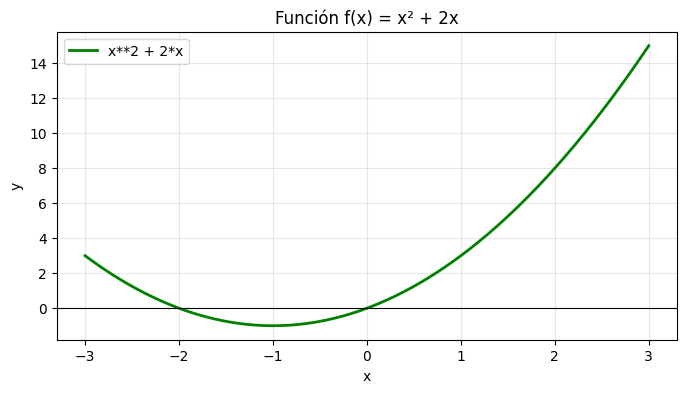

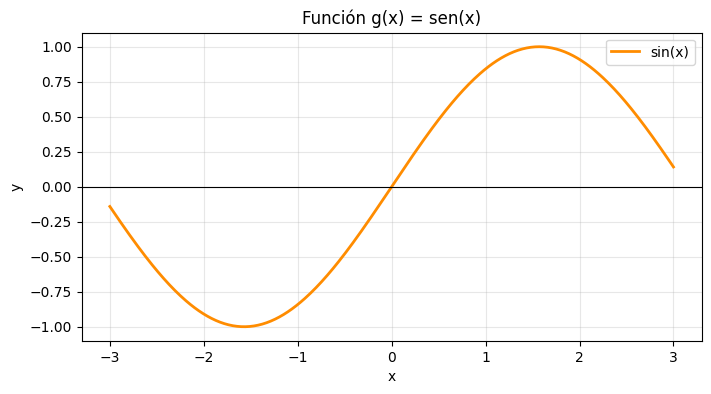

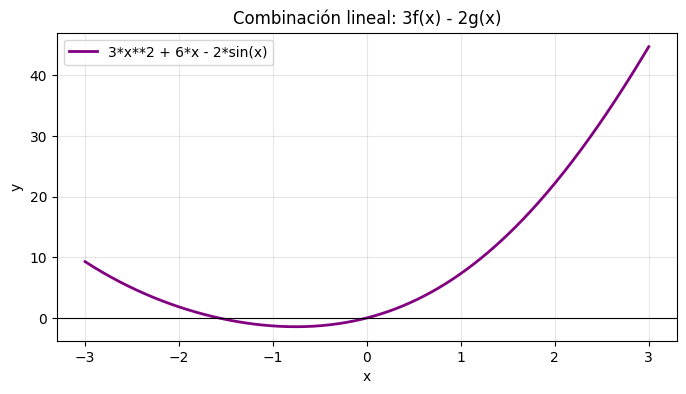

In [4]:
# ============================================================
# 3. GRÁFICAS DE APOYO
# ============================================================

graficar_funcion(f, -3, 3, "Función f(x) = x² + 2x", color="green")
graficar_funcion(g, -3, 3, "Función g(x) = sen(x)", color="darkorange")
graficar_funcion(a*f + b*g, -3, 3, "Combinación lineal: 3f(x) - 2g(x)", color="purple")


## 5 ejemplos de integrales indefinidas con contexto ambiental

In [13]:
# ============================================================
# 4. EJEMPLOS DE INTEGRALES INDEFINIDAS
# ============================================================

from IPython.display import display, Markdown

ejemplos_indefinidas = [
    {
        "ejercicio": 1,
        "contexto": "La tasa instantánea de captura de carbono de una cobertura vegetal urbana varía con el tiempo según un modelo polinómico. Determinar la función acumulada de carbono.",
        "integral": r"\int (4t^3-6t+5)\,dt"
    },
    {
        "ejercicio": 2,
        "contexto": "La tasa de descomposición de materia orgánica en un humedal disminuye exponencialmente con el tiempo. Encontrar la función acumulada asociada.",
        "integral": r"\int 8e^{-0.4t}\,dt"
    },
    {
        "ejercicio": 3,
        "contexto": "La infiltración de agua en un suelo agrícola depende de la profundidad $z$. Hallar la antiderivada general.",
        "integral": r"\int \frac{2z}{1+z^2}\,dz"
    },
    {
        "ejercicio": 4,
        "contexto": "La radiación solar útil para un sistema de bombeo fotovoltaico sigue una variación periódica durante el día. Determinar la función acumulada.",
        "integral": r"\int 5\cos\left(\frac{\pi t}{12}\right)\,dt"
    },
    {
        "ejercicio": 5,
        "contexto": "La concentración de un nutriente disuelto en una microcuenca cambia con la distancia $x$ y sigue un modelo racional simple. Hallar la antiderivada.",
        "integral": r"\int \frac{3}{x+2}\,dx"
    }
]
display(Markdown("## 5 ejemplos de integrales indefinidas con contexto ambiental"))

for ej in ejemplos_indefinidas:
    display(Markdown(f"""
### Ejercicio {ej['ejercicio']}

**Contexto ambiental:**
{ej['contexto']}

**Integral a resolver:**
$$
{ej['integral']}
$$

---
"""))

## 5 ejemplos de integrales indefinidas con contexto ambiental


### Ejercicio 1

**Contexto ambiental:**  
La tasa instantánea de captura de carbono de una cobertura vegetal urbana varía con el tiempo según un modelo polinómico. Determinar la función acumulada de carbono.

**Integral a resolver:**  
$$
\int (4t^3-6t+5)\,dt
$$

---



### Ejercicio 2

**Contexto ambiental:**  
La tasa de descomposición de materia orgánica en un humedal disminuye exponencialmente con el tiempo. Encontrar la función acumulada asociada.

**Integral a resolver:**  
$$
\int 8e^{-0.4t}\,dt
$$

---



### Ejercicio 3

**Contexto ambiental:**  
La infiltración de agua en un suelo agrícola depende de la profundidad $z$. Hallar la antiderivada general.

**Integral a resolver:**  
$$
\int \frac{2z}{1+z^2}\,dz
$$

---



### Ejercicio 4

**Contexto ambiental:**  
La radiación solar útil para un sistema de bombeo fotovoltaico sigue una variación periódica durante el día. Determinar la función acumulada.

**Integral a resolver:**  
$$
\int 5\cos\left(\frac{\pi t}{12}\right)\,dt
$$

---



### Ejercicio 5

**Contexto ambiental:**  
La concentración de un nutriente disuelto en una microcuenca cambia con la distancia $x$ y sigue un modelo racional simple. Hallar la antiderivada.

**Integral a resolver:**  
$$
\int \frac{3}{x+2}\,dx
$$

---


## 8 ejemplos de integrales definidas con contexto ambiental

In [14]:
# ============================================================
# 5. EJEMPLOS DE INTEGRALES DEFINIDAS
# ============================================================

from IPython.display import display, Markdown

ejemplos_definidas = [
    {
        "ejercicio": 1,
        "contexto": "La tasa de ingreso de agua a un reservorio comunitario durante una lluvia está dada por $q(t)=5t+2$, con $t$ en horas.",
        "integral": r"\int_0^4 (5t+2)\,dt",
        "interpretacion": "Volumen total ingresado en 4 horas."
    },
    {
        "ejercicio": 2,
        "contexto": "La concentración de un contaminante en un canal de drenaje agrícola se modela por $c(t)=12e^{-0.5t}$.",
        "integral": r"\int_0^6 12e^{-0.5t}\,dt",
        "interpretacion": "Carga contaminante acumulada."
    },
    {
        "ejercicio": 3,
        "contexto": "La potencia instantánea de un panel solar en una estación ambiental sigue $P(t)=300\sin\left(\frac{\pi t}{12}\right)$, para $t\in[0,12]$.",
        "integral": r"\int_0^{12} 300\sin\left(\frac{\pi t}{12}\right)\,dt",
        "interpretacion": "Energía solar acumulada durante el día."
    },
    {
        "ejercicio": 4,
        "contexto": "La tasa de captura de CO$_2$ por una franja de reforestación se modela como $r(t)=2t^2+1$.",
        "integral": r"\int_1^5 (2t^2+1)\,dt",
        "interpretacion": "Captura total en ese periodo."
    },
    {
        "ejercicio": 5,
        "contexto": "La velocidad de transporte de sedimentos a lo largo de una quebrada es $s(x)=x^2+3x$.",
        "integral": r"\int_0^3 (x^2+3x)\,dx",
        "interpretacion": "Sedimento acumulado transportado."
    },
    {
        "ejercicio": 6,
        "contexto": "La evapotranspiración diaria de un cultivo agroforestal está dada por $E(t)=4+\cos(t)$.",
        "integral": r"\int_0^{2\pi} (4+\cos t)\,dt",
        "interpretacion": "Pérdida total de agua en el periodo."
    },
    {
        "ejercicio": 7,
        "contexto": "La emisión horaria de gases en una zona industrial sigue $g(t)=10-0.8t$.",
        "integral": r"\int_0^8 (10-0.8t)\,dt",
        "interpretacion": "Emisión total producida."
    },
    {
        "ejercicio": 8,
        "contexto": "La variación de oxígeno disuelto en una laguna tiene comportamiento oscilatorio: $v(t)=2\sin\left(\frac{\pi t}{4}\right)$.",
        "integral": r"\int_0^8 2\sin\left(\frac{\pi t}{4}\right)\,dt",
        "interpretacion": "Cambio neto de oxígeno en el intervalo."
    }
]

display(Markdown("## 8 ejemplos de integrales definidas con contexto ambiental"))

for ej in ejemplos_definidas:
    display(Markdown(f"""
### Ejercicio {ej['ejercicio']}

**Contexto ambiental:**
{ej['contexto']}

**Integral definida a resolver:**
$$
{ej['integral']}
$$

**Interpretación:**
{ej['interpretacion']}

---
"""))


<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3159/582459620.py:22: SyntaxWarning: invalid escape sequence '\s'
  "contexto": "La potencia instantánea de un panel solar en una estación ambiental sigue $P(t)=300\sin\left(\frac{\pi t}{12}\right)$, para $t\in[0,12]$.",
/tmp/ipykernel_3159/582459620.py:40: SyntaxWarning: invalid escape sequence '\c'
  "contexto": "La evapotranspiración diaria de un cultivo agroforestal está dada por $E(t)=4+\cos(t)$.",
/tmp/ipykernel_3159/582459620.py:52: SyntaxWarning: invalid escape sequence '\s'
  "contexto": "La variación de oxígeno disuelto en una laguna tiene comportamiento oscilatorio: $v(t)=2\sin\left(\frac{\pi t}{4}\right)$.",


## 8 ejemplos de integrales definidas con contexto ambiental


### Ejercicio 1

**Contexto ambiental:**  
La tasa de ingreso de agua a un reservorio comunitario durante una lluvia está dada por $q(t)=5t+2$, con $t$ en horas.

**Integral definida a resolver:**  
$$
\int_0^4 (5t+2)\,dt
$$

**Interpretación:**  
Volumen total ingresado en 4 horas.

---



### Ejercicio 2

**Contexto ambiental:**  
La concentración de un contaminante en un canal de drenaje agrícola se modela por $c(t)=12e^{-0.5t}$.

**Integral definida a resolver:**  
$$
\int_0^6 12e^{-0.5t}\,dt
$$

**Interpretación:**  
Carga contaminante acumulada.

---



### Ejercicio 3

**Contexto ambiental:**  
La potencia instantánea de un panel solar en una estación ambiental sigue $P(t)=300\sin\left(rac{\pi t}{12}ight)$, para $t\in[0,12]$.

**Integral definida a resolver:**  
$$
\int_0^{12} 300\sin\left(\frac{\pi t}{12}\right)\,dt
$$

**Interpretación:**  
Energía solar acumulada durante el día.

---



### Ejercicio 4

**Contexto ambiental:**  
La tasa de captura de CO$_2$ por una franja de reforestación se modela como $r(t)=2t^2+1$.

**Integral definida a resolver:**  
$$
\int_1^5 (2t^2+1)\,dt
$$

**Interpretación:**  
Captura total en ese periodo.

---



### Ejercicio 5

**Contexto ambiental:**  
La velocidad de transporte de sedimentos a lo largo de una quebrada es $s(x)=x^2+3x$.

**Integral definida a resolver:**  
$$
\int_0^3 (x^2+3x)\,dx
$$

**Interpretación:**  
Sedimento acumulado transportado.

---



### Ejercicio 6

**Contexto ambiental:**  
La evapotranspiración diaria de un cultivo agroforestal está dada por $E(t)=4+\cos(t)$.

**Integral definida a resolver:**  
$$
\int_0^{2\pi} (4+\cos t)\,dt
$$

**Interpretación:**  
Pérdida total de agua en el periodo.

---



### Ejercicio 7

**Contexto ambiental:**  
La emisión horaria de gases en una zona industrial sigue $g(t)=10-0.8t$.

**Integral definida a resolver:**  
$$
\int_0^8 (10-0.8t)\,dt
$$

**Interpretación:**  
Emisión total producida.

---



### Ejercicio 8

**Contexto ambiental:**  
La variación de oxígeno disuelto en una laguna tiene comportamiento oscilatorio: $v(t)=2\sin\left(rac{\pi t}{4}ight)$.

**Integral definida a resolver:**  
$$
\int_0^8 2\sin\left(\frac{\pi t}{4}\right)\,dt
$$

**Interpretación:**  
Cambio neto de oxígeno en el intervalo.

---


## Verificación simbólica de un ejemplo

In [21]:
# ============================================================
# 6. DESARRROLLO
# ============================================================

from IPython.display import display, Markdown
import sympy as sp

display(Markdown("## DESARRROLLO"))

# Variables y ejemplos
x = sp.symbols('x', real=True)
ejemplo_indef = 3*x**2 - 4*x + 1
ejemplo_def = x*sp.exp(-x)

# ------------------------------------------------------------
# Ejemplo 1: Integral indefinida
# ------------------------------------------------------------
display(Markdown("### Ejemplo 1. Integral indefinida"))

resultado_indef = sp.integrate(ejemplo_indef, x)

display(Markdown("**Integral a resolver:**"))
display(sp.Eq(sp.Symbol("I_1"), sp.Integral(ejemplo_indef, x)))

display(Markdown("**Antiderivada obtenida con SymPy:**"))
display(sp.Eq(sp.Symbol("I_1"), resultado_indef + sp.Symbol("C")))

display(Markdown(
    "**Lectura:** la integral indefinida representa una familia de funciones "
    "cuya derivada vuelve al integrando original."
))

# ------------------------------------------------------------
# Ejemplo 2: Integral definida
# ------------------------------------------------------------
display(Markdown("### Ejemplo 2. Integral definida"))

a, b = 0, 3
resultado_def = sp.integrate(ejemplo_def, (x, a, b))
F = sp.integrate(ejemplo_def, x)

display(Markdown("**Integral a resolver:**"))
display(sp.Eq(sp.Symbol("I_2"), sp.Integral(ejemplo_def, (x, a, b))))

display(Markdown("**Paso 1. Hallar la antiderivada:**"))
display(sp.Eq(sp.Symbol("F(x)"), F))

display(Markdown("**Paso 2. Evaluar en los límites usando el Teorema Fundamental del Cálculo:**"))
display(sp.Eq(
    sp.Symbol("I_2"),
    sp.Symbol("F(3)") - sp.Symbol("F(0)")
))

display(Markdown("**Paso 3. Sustitución explícita:**"))
display(sp.Eq(
    sp.Symbol("I_2"),
    sp.simplify(F.subs(x, b) - F.subs(x, a))
))

display(Markdown("**Resultado exacto:**"))
display(sp.Eq(sp.Symbol("I_2"), resultado_def))

display(Markdown("**Valor aproximado:**"))
display(Markdown(f"$$I_2 \\approx {float(sp.N(resultado_def)):.6f}$$"))

display(Markdown(
    "**Interpretación:** la integral definida entrega un valor numérico que representa "
    "la acumulación total de la función en el intervalo considerado."
))

## DESARRROLLO

### Ejemplo 1. Integral indefinida

**Integral a resolver:**

     ⌠                    
     ⎮ ⎛   2          ⎞   
I₁ = ⎮ ⎝3⋅x  - 4⋅x + 1⎠ dx
     ⌡                    

**Antiderivada obtenida con SymPy:**

...

**Resultado exacto:**

            -3
I₂ = 1 - 4⋅ℯ  

**Valor aproximado:**

$$I_2 \approx 0.800852$$

**Interpretación:** la integral definida entrega un valor numérico que representa la acumulación total de la función en el intervalo considerado.

## Plantilla para que el estudiante pruebe sus propios ejercicios

In [22]:
# ============================================================
# PLANTILLA: INTEGRAL DEFINIDA
# El estudiante solo debe cambiar:
# 1) la función
# 2) el límite inferior
# 3) el límite superior
# ============================================================

from IPython.display import display, Markdown
import sympy as sp

# Variable simbólica
x = sp.symbols('x', real=True)

# ------------------------------------------------------------
# CAMBIAR SOLO ESTAS TRES LÍNEAS
# ------------------------------------------------------------
funcion = x**2 + sp.sin(x)   # <- Cambiar la función
limite_inferior = 0          # <- Cambiar el límite inferior
limite_superior = 2          # <- Cambiar el límite superior

# ------------------------------------------------------------
# NO MODIFICAR DESDE AQUÍ
# ------------------------------------------------------------
integral_definida = sp.integrate(funcion, (x, limite_inferior, limite_superior))

display(Markdown("## Plantilla para resolver una integral definida"))

display(Markdown("### Función ingresada"))
display(sp.Eq(sp.Symbol("f(x)"), funcion))

display(Markdown("### Integral definida"))
display(sp.Eq(
    sp.Symbol("I"),
    sp.Integral(funcion, (x, limite_inferior, limite_superior))
))

display(Markdown("### Resultado exacto"))
display(sp.Eq(sp.Symbol("I"), integral_definida))

display(Markdown("### Valor aproximado"))
display(Markdown(f"$$I \\approx {float(sp.N(integral_definida)):.6f}$$"))

## Plantilla para resolver una integral definida

### Función ingresada

        2         
f(x) = x  + sin(x)

### Integral definida

    2                 
    ⌠                 
    ⎮ ⎛ 2         ⎞   
I = ⎮ ⎝x  + sin(x)⎠ dx
    ⌡                 
    0                 

### Resultado exacto

I = 11/3 - cos(2)

### Valor aproximado

$$I \approx 4.082814$$